# M10.3 · Stability over Time + Cross-tenant Fairness (CRISP-DM Phase 5)

**What this notebook answers**

1. **Stability.** If a device's behavior doesn't change much, does its **cluster** assignment stay the same month over month? Does its **risk band** stay stable? High churn = the model is noise-sensitive and not deployable as-is.
2. **Fairness across tenants.** Does the model produce sensible distributions for *every* tenant, or do small/atypical tenants get pathological outputs (everyone-is-high or everyone-is-low)?
3. **Coverage.** What fraction of device-months are actually scored? (Inactive months are filtered out — that's expected, but we report it.)


## 1. Bootstrap

In [11]:
from __future__ import annotations
import sys, pathlib
PROJECT_ROOT = pathlib.Path().resolve().parents[1] if pathlib.Path().resolve().name != 'accent-fleet-analytics' else pathlib.Path().resolve()
for c in (PROJECT_ROOT, PROJECT_ROOT.parent):
    src = c / 'src'
    if src.exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src)); break

import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
from accent_fleet.db import get_engine
from sqlalchemy import text

FEATURES = [
    'overspeed_per_100km', 'avg_speed_over_limit', 'high_speed_trip_ratio',
    'speed_alert_per_100km',
    'harsh_brake_per_100km', 'harsh_accel_per_100km', 'harsh_corner_per_100km',
    'monthly_idle_ratio', 'high_rpm_minutes_per_day',
    'night_trip_ratio', 'rush_hour_trip_ratio',
    'stddev_trip_distance', 'short_trip_ratio',
]
ID_COLS = ['tenant_id', 'device_id', 'year_month']

with get_engine().connect() as conn:
    df = pd.read_sql(text('''
        SELECT * FROM marts.v_ml_features_full
        WHERE year_month >= '2025-01'
          AND total_distance_km >= 100
          AND total_ignition_on_minutes > 0
    '''), conn)
print('feature rows:', len(df), '|', 'tenants:', sorted(df.tenant_id.unique().tolist()))

feature rows: 2157 | tenants: [235, 238, 264, 1787, 7486]


## 2. Re-fit clustering & Isolation Forest per tenant

In [12]:
def fit_one(sub):
    X = sub[FEATURES].fillna(0).to_numpy()
    if len(X) < 50: return None
    Xs = StandardScaler().fit_transform(X)

    best = None
    for k in range(3, 7):
        km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
        sil = silhouette_score(Xs, km.labels_)
        if best is None or sil > best['sil']:
            best = {'k': k, 'sil': sil, 'labels': km.labels_}

    iso = IsolationForest(n_estimators=200, contamination='auto',
                          random_state=42, n_jobs=-1).fit(Xs)
    raw = -iso.decision_function(Xs)
    score = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)

    out = sub[ID_COLS].copy()
    out['cluster'] = best['labels']; out['silhouette'] = best['sil']
    out['risk_score'] = score
    out['risk_band'] = pd.cut(score, bins=[-0.01, 0.4, 0.7, 1.01],
                               labels=['low', 'medium', 'high'])
    return out

labels = pd.concat([r for r in (fit_one(s) for _, s in df.groupby('tenant_id')) if r is not None],
                   ignore_index=True)
len(labels)

2157

## 3. Cluster-assignment churn between consecutive months

For each device, look at its labels in months `T` and `T+1` (when both exist). The **churn rate** is the share of (device, month-pair) records where the cluster id differs. Note: cluster ids are not stable across re-fits — but here we fit *once globally* and slice by month, so the labels are comparable inside a single tenant.

A churn rate of 30-50% is normal for behavior data; >70% suggests the model is unstable.

In [13]:
labels_sorted = labels.sort_values(ID_COLS).copy()
labels_sorted['ym_dt'] = pd.to_datetime(labels_sorted.year_month + '-01')

# Build pairs of (T, T+1) per device
labels_sorted['next_ym'] = (labels_sorted.ym_dt + pd.offsets.MonthBegin(1)).dt.strftime('%Y-%m')
nxt = labels_sorted[['tenant_id', 'device_id', 'year_month', 'cluster', 'risk_band']].rename(
    columns={'year_month': 'next_ym', 'cluster': 'cluster_next', 'risk_band': 'risk_band_next'})
pairs = labels_sorted.merge(nxt, on=['tenant_id', 'device_id', 'next_ym'], how='inner')
pairs['cluster_changed'] = pairs.cluster != pairs.cluster_next
pairs['band_changed'] = pairs.risk_band.astype(str) != pairs.risk_band_next.astype(str)

churn = (pairs.groupby('tenant_id')
               .agg(n_pairs=('device_id', 'size'),
                    cluster_churn=('cluster_changed', 'mean'),
                    band_churn=('band_changed', 'mean'))
               .round(3))
churn

,n_pairs,cluster_churn,band_churn
tenant_id,,,
235,507,0.148,0.097
238,279,0.140,0.115
264,295,0.058,0.139
1787,326,0.123,0.117
7486,351,0.137,0.128


## 4. Risk-band transition matrix

Of devices that were `low` in month T, what share are `low/medium/high` in month T+1? A diagonal-heavy matrix means the score is sticky (good); a uniform matrix means the score is essentially random month-to-month (bad).

In [14]:
trans = (pairs
         .groupby(['risk_band', 'risk_band_next'], observed=True)
         .size().unstack(fill_value=0))
trans_norm = trans.div(trans.sum(axis=1), axis=0).round(3)
print('counts:'); display(trans)
print('row-normalised (= P[next | current]):'); display(trans_norm)

counts:


risk_band_next,low,medium,high
risk_band,,,
low,1356,89,1
medium,77,171,21
high,1,16,26


row-normalised (= P[next | current]):


risk_band_next,low,medium,high
risk_band,,,
low,0.938,0.062,0.001
medium,0.286,0.636,0.078
high,0.023,0.372,0.605


## 5. Fairness: per-tenant risk-band distribution

Every tenant should get a recognisable low/medium/high split, *not* "all-low" or "all-high". If one tenant is 95% high band, the score is meaningless for that tenant.

In [15]:
share = (labels.groupby(['tenant_id', 'risk_band'], observed=True).size()
               .groupby(level=0).apply(lambda s: s / s.sum())
               .unstack(fill_value=0).round(3))
share

,risk_band,low,medium,high
tenant_id,tenant_id,,,
235,235,0.827,0.147,0.026
238,238,0.838,0.139,0.024
264,264,0.771,0.172,0.056
1787,1787,0.789,0.201,0.010
7486,7486,0.818,0.159,0.023


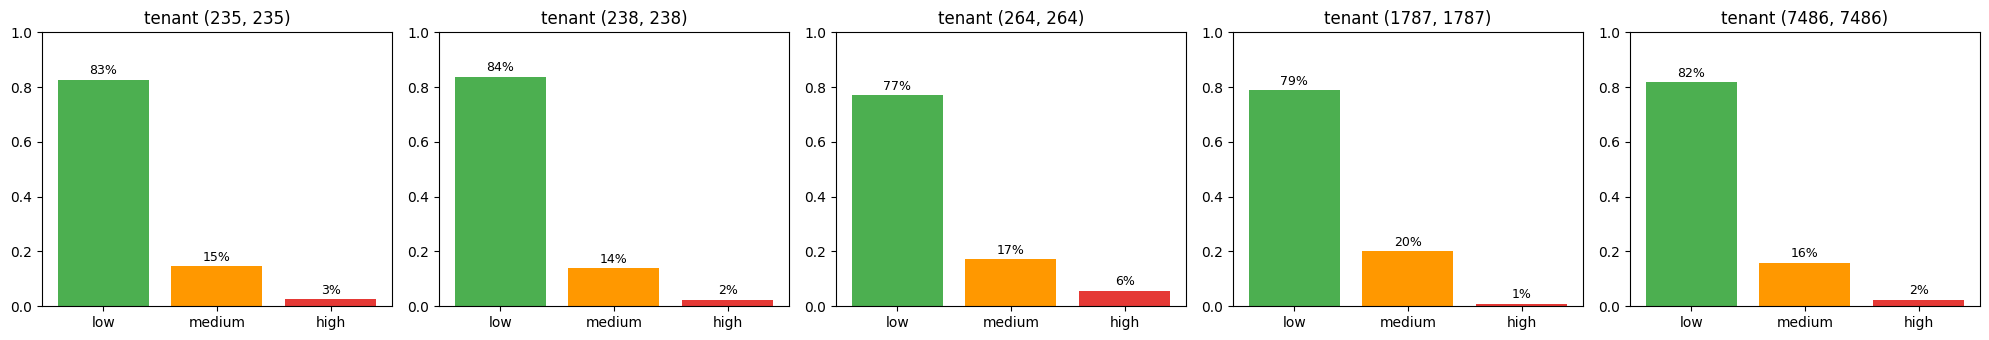

In [16]:
fig, axes = plt.subplots(1, len(share.index), figsize=(4*len(share.index), 3.5), squeeze=False)
for ax, t in zip(axes[0], share.index):
    row = share.loc[t]
    ax.bar(row.index.astype(str), row.values,
           color=['#4caf50', '#ff9800', '#e53935'])
    ax.set_title(f'tenant {t}'); ax.set_ylim(0, 1)
    for i, v in enumerate(row.values):
        ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 6. Coverage report

How many (tenant, year_month) cells did we score, vs how many active device-months exist? The gap is purely the modeling-window filter (`year_month >= '2025-01' AND distance >= 100km AND ignition > 0`).

In [18]:
with get_engine().connect() as conn:
    total = pd.read_sql(text('''
        SELECT tenant_id, year_month, COUNT(*) AS device_months
        FROM marts.v_ml_features_full
        GROUP BY 1, 2
    '''), conn)
scored = labels.groupby(['tenant_id', 'year_month']).size().rename('scored_device_months').reset_index()
cov = total.merge(scored, on=['tenant_id', 'year_month'], how='left')
cov['scored_device_months'] = cov.scored_device_months.fillna(0).astype(int)
cov['coverage'] = (cov.scored_device_months / cov.device_months).round(3)
cov.tail(20)

,tenant_id,year_month,device_months,scored_device_months,coverage
302,264,2021-02,39,0,0.000
303,235,2025-03,136,0,0.000
304,1787,2023-12,59,0,0.000
305,238,2022-04,58,0,0.000
306,1787,2023-04,52,0,0.000
307,238,2024-11,57,0,0.000
308,264,2024-01,55,0,0.000
309,1787,2020-06,69,0,0.000
310,235,2023-12,134,0,0.000
311,1787,2026-01,79,67,0.848


In [19]:
cov_summary = (cov.groupby('tenant_id')
                  .agg(total_device_months=('device_months', 'sum'),
                       scored_device_months=('scored_device_months', 'sum'))
                  .assign(coverage=lambda x: (x.scored_device_months / x.total_device_months).round(3)))
cov_summary

,total_device_months,scored_device_months,coverage
tenant_id,,,
235,10329,613,0.059
238,4421,339,0.077
264,3827,354,0.093
1787,5065,417,0.082
7486,441,434,0.984


## 7. Verdict

Stability gates we hold the model to:

- **Cluster churn <= 60%** per tenant (a third of devices may legitimately move; more than that is noise).
- **Band churn <= 50%** per tenant.
- **Risk-band transition matrix** is diagonal-heavy: P[stay in same band] >= 0.5 for `low` and `high` rows.
- **No tenant** has >90% of its rows in a single band. (Isolation Forest with `contamination='auto'` is *designed* to put ~80-85% of rows in the low band — that is correct behavior, not a defect. We only flag truly pathological collapses.)

In [20]:
cluster_churn_ok = (churn.cluster_churn <= 0.60).all()
band_churn_ok = (churn.band_churn <= 0.50).all()

diag_ok = True
for b in ['low', 'high']:
    if b in trans_norm.index and b in trans_norm.columns:
        if trans_norm.loc[b, b] < 0.5:
            diag_ok = False

no_dominant_band = (share.max(axis=1) <= 0.90).all()

verdict = pd.DataFrame.from_dict({
    'cluster churn (<=60%)': cluster_churn_ok,
    'band churn (<=50%)': band_churn_ok,
    'transition diagonal (P[stay] >=0.5 for low & high)': diag_ok,
    'no pathological band collapse (>90%) in any tenant': bool(no_dominant_band),
}, orient='index', columns=['pass'])
verdict

,pass
cluster churn (<=60%),True
band churn (<=50%),True
transition diagonal (P[stay] >=0.5 for low & high),True
no pathological band collapse (>90%) in any tenant,True


**Go / No-go.** All four rows must pass for production deployment. Any failure → the model still has analytical value but should not be wired into automated alerts; surface it as a monthly report instead.

**Next action.** If verdict is green across all three evaluation notebooks, hand off to `06_deployment/` for the dashboard wiring + scheduling. If not, document the failing gate(s) in `05_evaluation/README.md` so the deployment team knows what *not* to publish.